In [3]:
#setup Stuff

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timezone

with open("adData/ads_viewed.json") as f:
    adData = json.load(f)

In [7]:
#-> dataframe

records = []
for entry in adData:
    ts = entry["timestamp"]
    dt = datetime.fromtimestamp(ts, tz=timezone.utc)

    # dig the advertiser name out of the nested label_values
    name = None
    for item in entry["label_values"]:
        if item.get("title") == "Owner":
            for d in item["dict"]:
                for field in d["dict"]:
                    if field["label"] == "Name":
                        name = field["value"]
    
    records.append({"datetime": dt, "hour": dt.hour, "advertiser": name})

df = pd.DataFrame(records)
print(df.head())
print(f"\nTotal views: {len(df)}")

hourly = df.groupby("hour").size().reindex(range(24), fill_value=0)
print(hourly)

                   datetime  hour       advertiser
0 2026-03-15 19:14:31+00:00    19            Dedar
1 2026-03-15 23:34:46+00:00    23  BIRDY GREY ð¥
2 2026-03-16 03:54:01+00:00     3                 
3 2026-03-17 01:39:48+00:00     1                 
4 2026-03-18 16:24:03+00:00    16         Rippling

Total views: 52
hour
0      2
1      1
2     16
3      7
4      2
5      1
6      0
7      1
8      1
9      0
10     0
11     0
12     2
13     1
14     1
15     0
16     7
17     0
18     1
19     3
20     0
21     0
22     1
23     5
dtype: int64


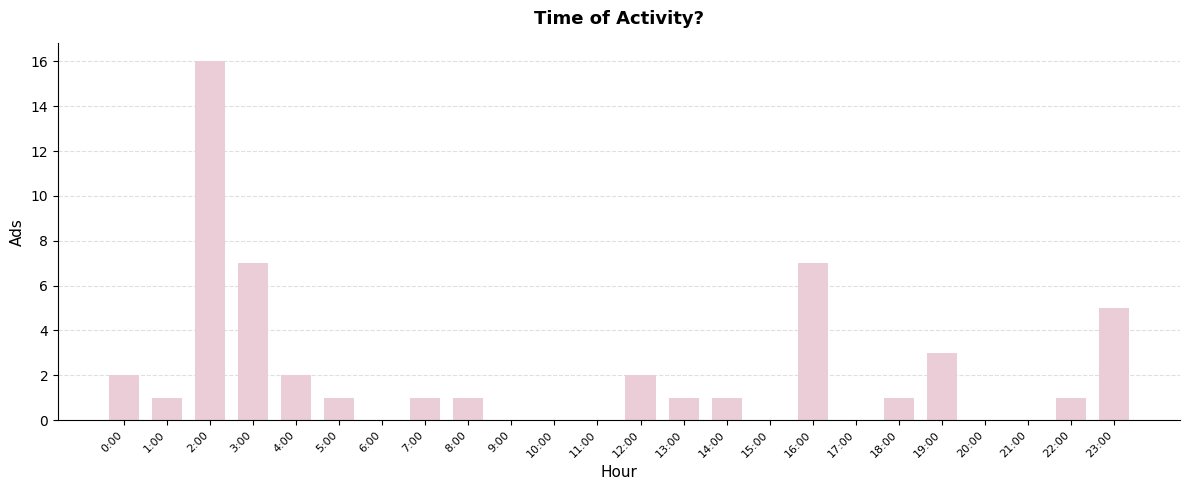

In [9]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(hourly.index, hourly.values, color="#EBCDD7", width=0.7, zorder=2)
ax.set_xlabel("Hour", fontsize=11)
ax.set_ylabel("Ads", fontsize=11)
ax.set_title("Time of Activity?", fontsize=13, fontweight="bold", pad=14)

hour_labels = [f"{h}:00" for h in range(24)]
ax.set_xticks(range(24))
ax.set_xticklabels(hour_labels, rotation=45, ha="right", fontsize=8)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))  # whole numbers only

ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)

plt.tight_layout()
plt.savefig("ad_impressions_by_hour.png", dpi=150)
plt.show()